# Frame Data

#### Why?
- Given the dataset o huose prices in california you are tasked with building a model to predict the median house price so that your company can dedcide on where to invest. Your model is put into a pipeline and used as on of the factors to tell the company where to invest. The current system is fragil and often wrong by 30%.

- Given that we have labled examples this seems to be a classic **supervised learning** task.
    - Each instance comes with a labeled output -> **Regression task** -> multiple regression problem.
    - Also a **univariate** -> Using thae data to predict a single number for each district.

#### Performance Measure **AKA Cost Function**
- For regression problems the RMSE is a typical go-to. 
- Ith the contexto f this problem we are asking how wrong is my model.
- Big misses (predicted value vs actual value) are punished harder! -> model trains to lower that...
- If alot of outliers then you may wanna use MAE as it's not as harsh for outliers.

#### Assumptions (IYKYK....)
- We are assuming our data is then used and the number goes into another model to be usedd to determine some sort of strategy. **BUT** what if the model just oook your number and labeled them as "cheap" , "medium", or "expensive" then you making this a regressions task is not correct as you dont need to worry abot getting the price right more classifying them right so this would then tell us to go with a "classification Task" approach... 




# Get the Data (Yay......)

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
from zlib import crc32

def load_housing_data():
    
    # define path
    tarball_path = Path("../data/housing.tgz")
    
    # Check if that is there and if not then make the files and pull data from the web
    if not tarball_path.is_file():
        Path("../data").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="../data", filter="data")
    return pd.read_csv(Path("../data/housing/housing.csv"))

# set it to a var
housing_full = load_housing_data()

# Lets get to kow the data!


In [ ]:
housing_full.info() #quick description of the data (types, count ect...)

# NOTE that the total bedrooms count is lower (watch out for this later)

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [20]:
# Check the count of the ocean object
housing_full["ocean_proximity"].value_counts()



ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [23]:
# Another quick look at some calculation on the data...
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


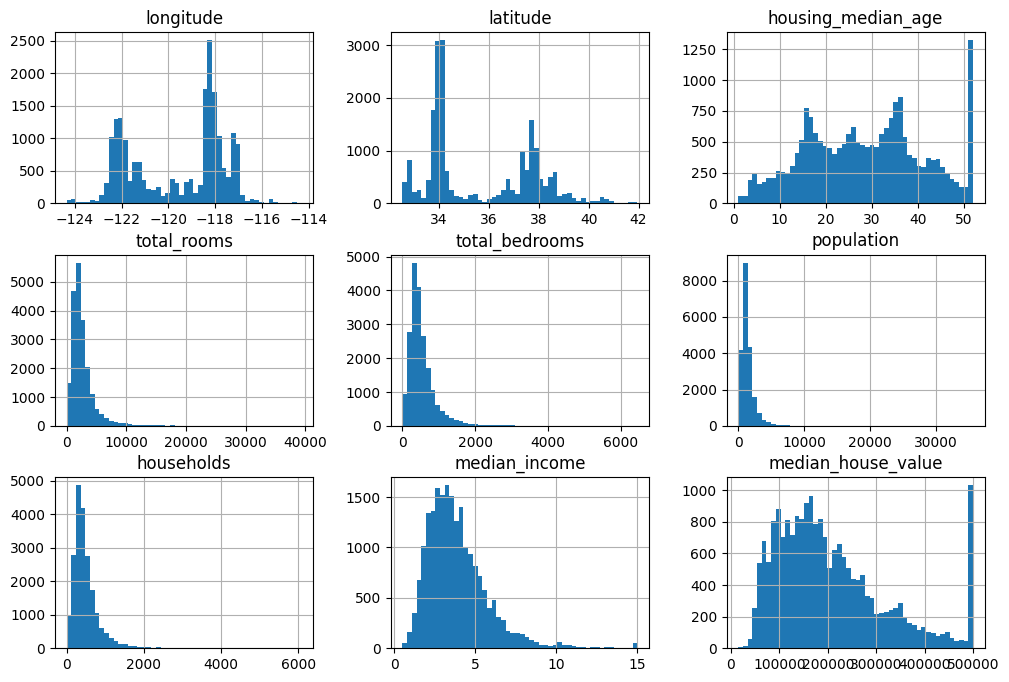

In [25]:
# Another option is to generate a histogram!
housing_full.hist(bins=50, figsize=(12,8))
plt.show()

# Note here that there are some things that don't make sense right away. This is where you would explore wit the souncrs and validate s oyou get a better understanding of caps and skews.
# Also note that there may need to be some "cleanup" as the outlier can make it harder for the algo to detect a pattern (Wanna smooth it out within reason)
# Tips on how to do this are given in a later chapter but worth pointing out!

# Lets create a test set

In [ ]:
# we wanna take some data and set it aside to test our new model on something it has not seen yet!
# 20% is a good rule of thumb!
import numpy as np
from zlib import crc32

def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indices = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]


rng = np.random.default_rng()
train_set, test_set = shuffle_and_split_data(housing_full, 0.2, rng)

len(train_set) # 16512

len(test_set) # 4128


# create  som sort of unique identifier so you can refe the smame test data!
def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

# use the row index as a hash unique value
housing_with_id = housing_full.reset_index() # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

# using someting stable so that we can rely on it hmmm latitude vals
housing_with_id["id"] = (housing_full["longitude"] * 1000
+ housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")



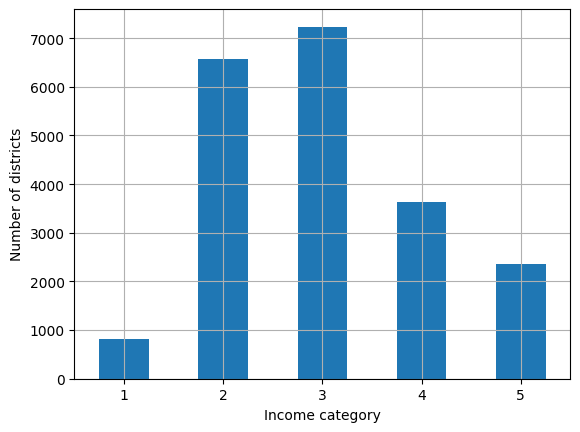

In [37]:
# Do the same with scikit learn lolz 2 lines :)
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)

housing_full["income_cat"] = pd.cut(housing_full["median_income"],
bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
labels=[1, 2, 3, 4, 5])

cat_counts = housing_full["income_cat"].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_train_set, strat_test_set = train_test_split(
housing_full, test_size=0.2, stratify=housing_full["income_cat"],
random_state=42)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)

# Drop Income Category
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

### Now lets Visulaize some data

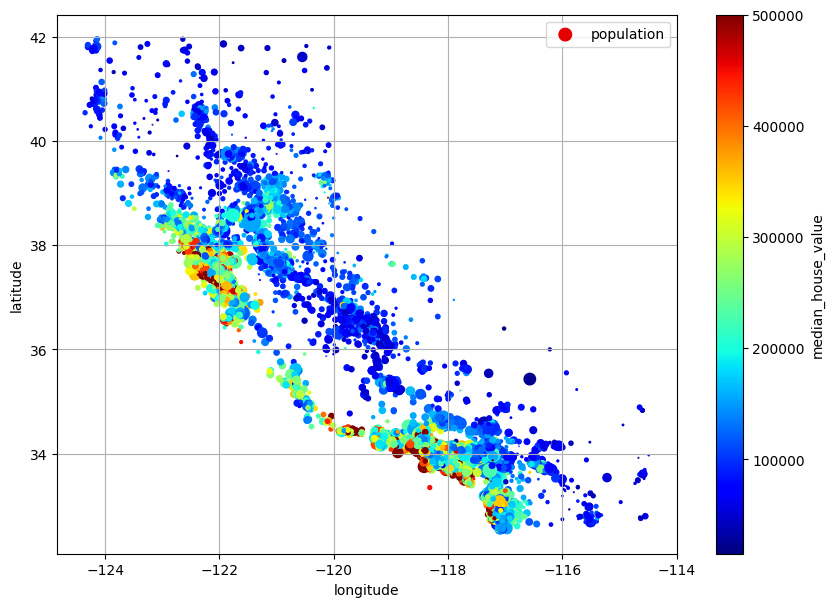

In [ ]:
# MAke a hard copy
housing = strat_train_set.copy()

# Plot it
housing.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    grid=True,
    s=housing["population"] / 100,
    label="population",
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    legend=True,
    sharex=True,
    figsize=(10, 7),
)
plt.show()